This Analysis is divided into 5 parts to answer 4 questions, with the first part with data cleaning:
1. Which countries truly dominated the Olympics?
2. Which countries were the most efficient?
3. How has the Olympics changed over time?
4. Did hosting the Olympics provide benefit to the country?

In [78]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset
df = pd.read_csv("summer_olympics_data.csv")

#Data Cleaning
df.drop(columns="notes", inplace=True)
df.fillna({"Medal":"No Medal"}, inplace=True)
df.fillna({"region":"Unknown"}, inplace=True)
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
print(df.isnull().sum())

categorical = [
    'Sex','Team','NOC',
    'City','Sport',
    'Event','Medal','region'
]
for col in categorical:
    df[col] = df[col].astype('category')
df['Won_Medal'] = df['Medal'].apply(
    lambda x: 0 if x == 'No Medal' else 1
)
df['Decade'] = (df['Year']//10)*10
df['Olympics_No'] = df['Year'].rank(method='dense').astype(int)

#First 5 rows of cleaned data
df.head()

ID            0
Name          0
Sex           0
Age        9030
Height    50500
Weight    52506
Team          0
NOC           0
Games         0
Year          0
City          0
Sport         0
Event         0
Medal         0
region        0
dtype: int64


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,City,Sport,Event,Medal,region,Won_Medal,Decade,Olympics_No
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0,1990,23
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0,2010,28
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0,1920,7
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,1,1900,2
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No Medal,Netherlands,0,1930,10


**PART-1-A** : Most dominant countries

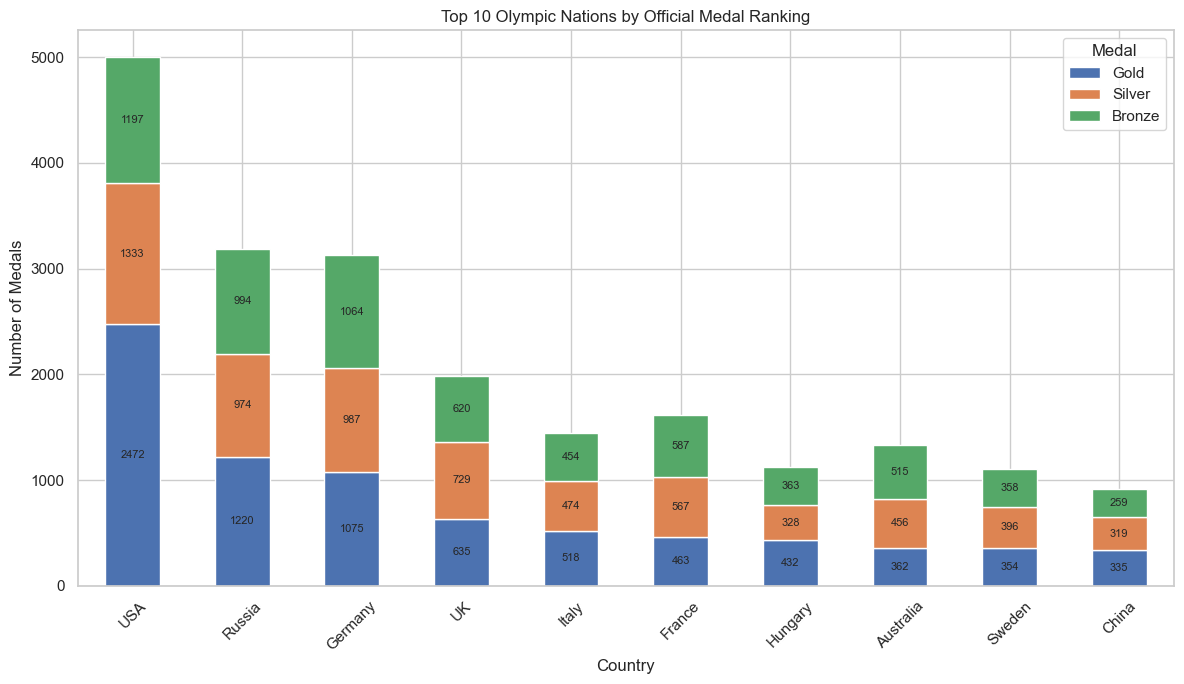

In [79]:
medal_table = (
    df[df['Medal'] != 'No Medal']
    .pivot_table(
        index='region',
        columns='Medal',
        values='Name',
        aggfunc='count',
        fill_value=0,
        observed=True
    )
)
medal_table = (
    medal_table
    .sort_values(
        by=['Gold', 'Silver', 'Bronze'],
        ascending=False
    )
)
top10 = medal_table.head(10)
sns.set_theme(style="whitegrid")
ax = top10[['Gold','Silver','Bronze']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title('Top 10 Olympic Nations by Official Medal Ranking')
plt.xlabel('Country')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.legend(title='Medal')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

**PART 1-B** : Most dominant countries by decade ( 2000s )

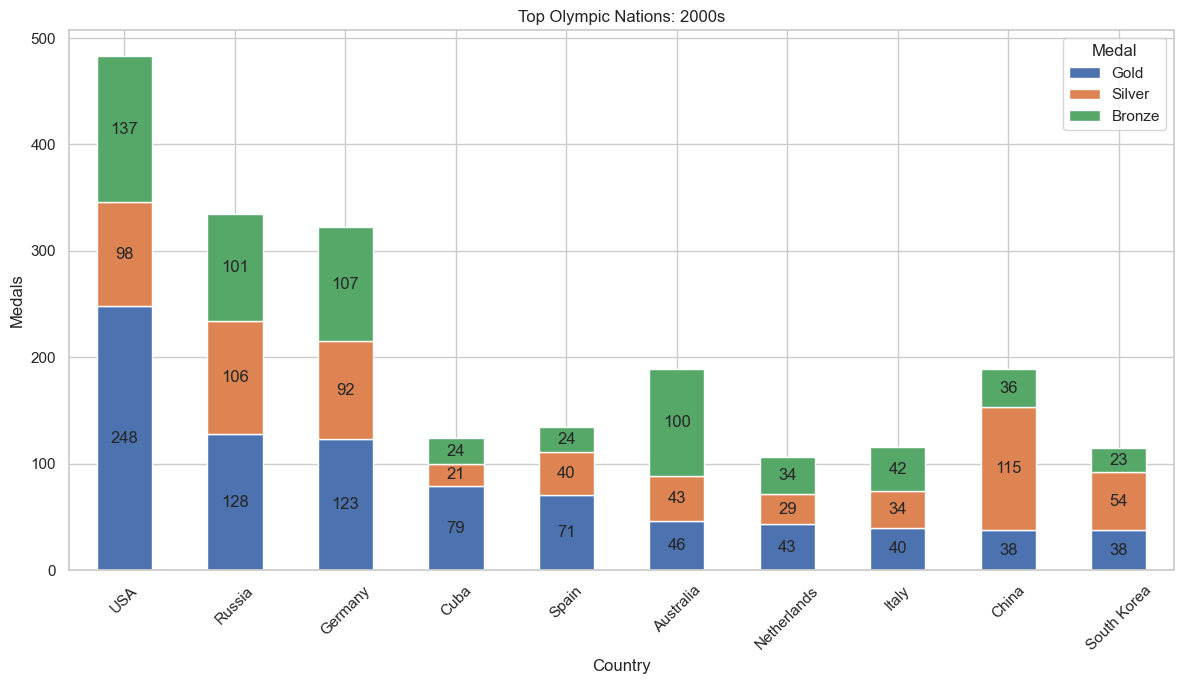

In [80]:
decade_medals = (
    df[df['Medal'] != 'No Medal']
    .pivot_table(
        index=['Decade','region'],
        columns='Medal',
        values='Name',
        aggfunc='count',
        fill_value=0,
        observed=True
    )
    .reset_index()
)
decade_medals = (
    decade_medals
    .sort_values(
        ['Decade','Gold','Silver','Bronze'],
        ascending=[True,False,False,False]
    )
)
d2000 = (
    decade_medals[
        decade_medals['Decade'] == 1990
    ]
    .head(10)
)
ax = d2000.set_index('region')[
    ['Gold','Silver','Bronze']
].plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title('Top Olympic Nations: 2000s')
plt.xlabel('Country')
plt.ylabel('Medals')
plt.legend(title='Medal')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.tight_layout()
plt.show()

**PART 2-A** : Most efficient countries


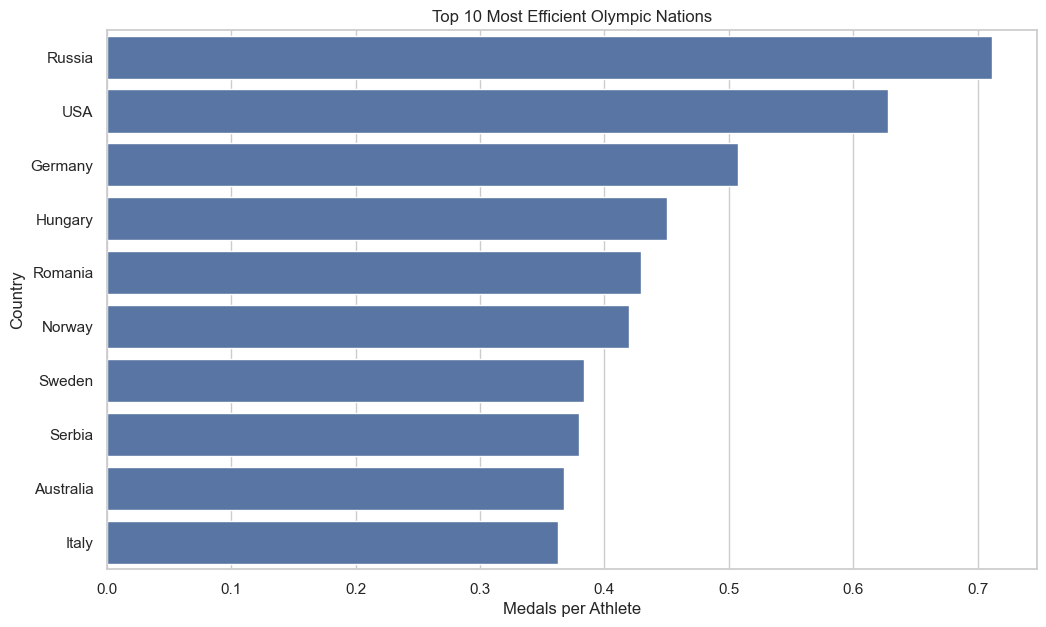

In [81]:
#Finding out total athletes by each country
athletes = (
    df.groupby('region',observed=False)['Name']
      .nunique()
      .reset_index(name='Total_Athletes')
)
#Total Medals won by each country
medals = (
    df[df['Medal'] != 'No Medal']
    .groupby('region',observed=False)
    .size()
    .reset_index(name='Total_Medals')
)

efficiency = athletes.merge(medals,on='region',how='left')
efficiency['Total_Medals'] = (efficiency['Total_Medals'].fillna(0)) #Countries with no medals get 0

efficiency['Medals_Per_Athlete'] = (efficiency['Total_Medals']/ efficiency['Total_Athletes'])

efficiency = efficiency[efficiency['Total_Athletes'] >= 500] #Removing countries with very few athletes
top10_efficiency = ( efficiency.sort_values('Medals_Per_Athlete',ascending=False).head(10))
top10_efficiency['region'] = top10_efficiency['region'].astype(str)

plt.figure(figsize=(12,7))
sns.barplot(
    data=top10_efficiency,
    x='Medals_Per_Athlete',
    y='region'
)
plt.title('Top 10 Most Efficient Olympic Nations')
plt.xlabel('Medals per Athlete')
plt.ylabel('Country')
plt.show()

**PART 2-B** : Medals per olympic appearence

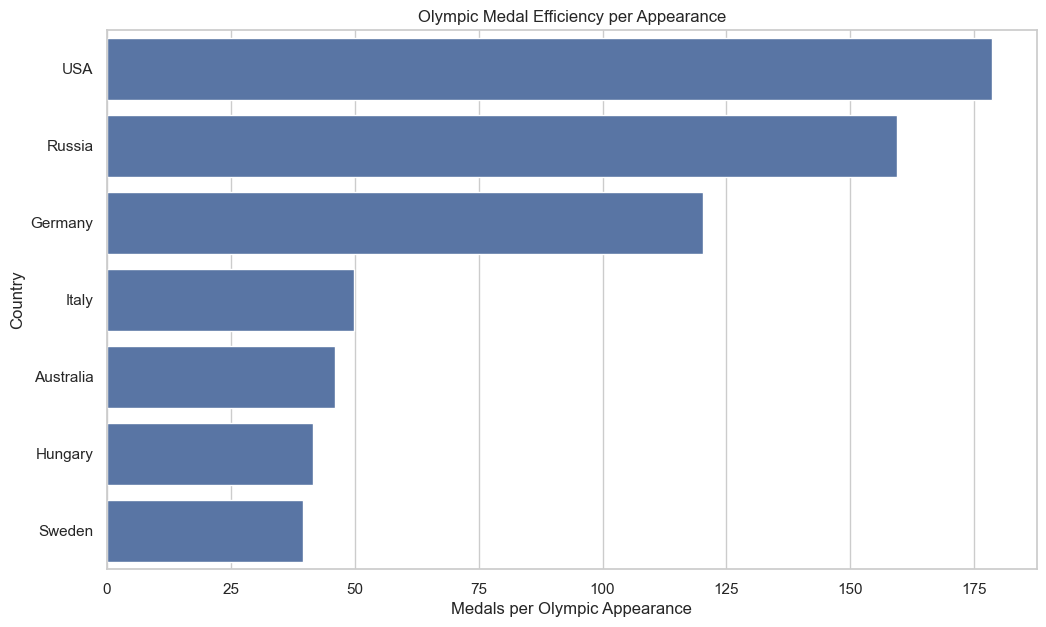

In [82]:
#PART 2-B
#MEDALS PER OLYMPIC APPEARENCE

#Finding out total appearences of each country
appearances = (
    df.groupby('region',observed=False)['Games']
    .nunique()
    .reset_index(name='Olympic_Appearances')
)
efficiency2 = appearances.merge(medals,on='region',how='left')
efficiency2['Total_Medals'] = (efficiency2['Total_Medals'].fillna(0))

efficiency2 = efficiency2[efficiency2['Olympic_Appearances'] >= 10] #Removing countries with very few appearences
efficiency2['Medals_Per_Appearance'] = (efficiency2['Total_Medals']/ efficiency2['Olympic_Appearances'])
top10_efficiency2 = (efficiency2.sort_values('Medals_Per_Appearance',ascending=False).head(10))
top10_efficiency2['region'] = top10_efficiency['region'].astype(str)

plt.figure(figsize=(12,7))
sns.barplot(
    data=top10_efficiency2,
    x='Medals_Per_Appearance',
    y='region'
)
plt.title('Olympic Medal Efficiency per Appearance')
plt.xlabel('Medals per Olympic Appearance')
plt.ylabel('Country')
plt.show()

**PART 3-A** :
Gender participation trend

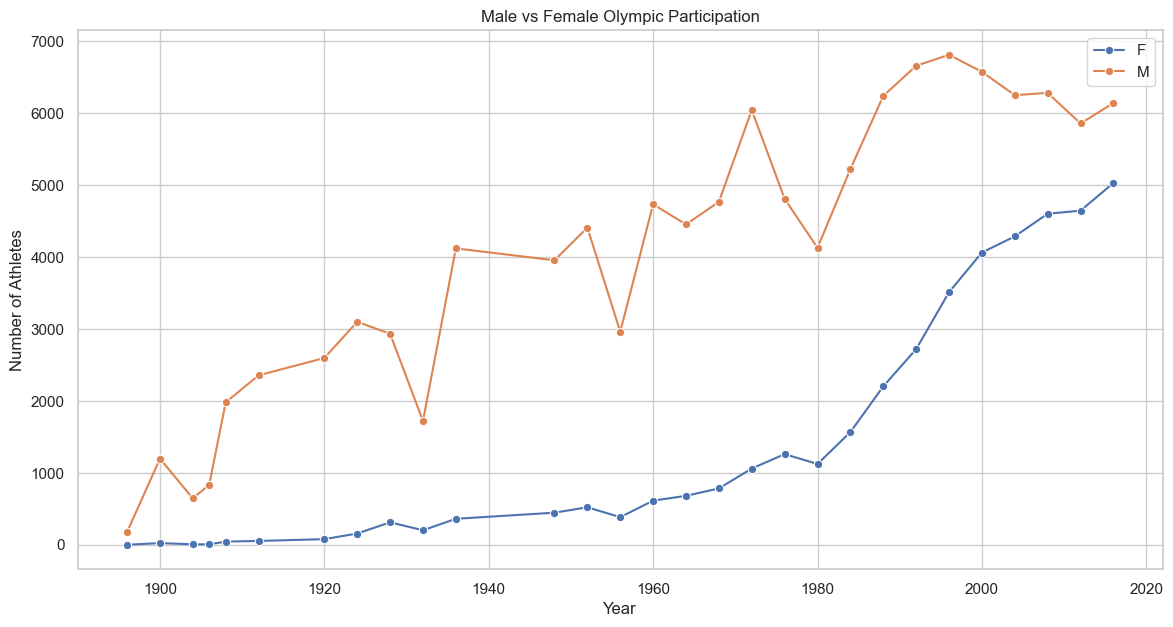

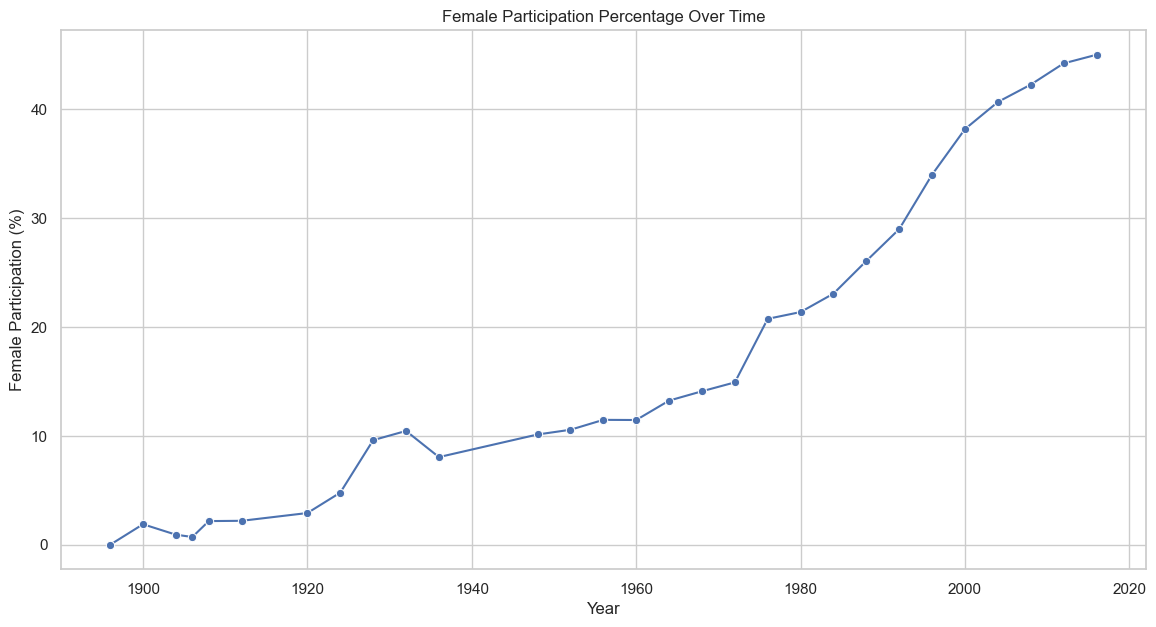

In [83]:
gender = (
    df.groupby(['Year','Sex'],observed=False)['Name']
    .nunique()
    .reset_index()
)
#Line chart to represent the trend
plt.figure(figsize=(14,7))
sns.lineplot(
    data=gender,
    x='Year',
    y='Name',
    hue='Sex',
    marker='o'
)
plt.title('Male vs Female Olympic Participation')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.legend()
plt.show()

#Finding out female percentage
gender_percent = (
    df.groupby(['Year','Sex'],observed=False)['Name']
    .nunique()
    .unstack()
)
gender_percent['Female_Percentage'] = (
    gender_percent['F']
    /
    (gender_percent['F'] + gender_percent['M'])
    * 100
)

plt.figure(figsize=(14,7))
sns.lineplot(
    x=gender_percent.index,
    y=gender_percent['Female_Percentage'],
    marker='o'
)
plt.title('Female Participation Percentage Over Time')
plt.xlabel('Year')
plt.ylabel('Female Participation (%)')
plt.show()

**PART 3-B** : Athlete physiology trend

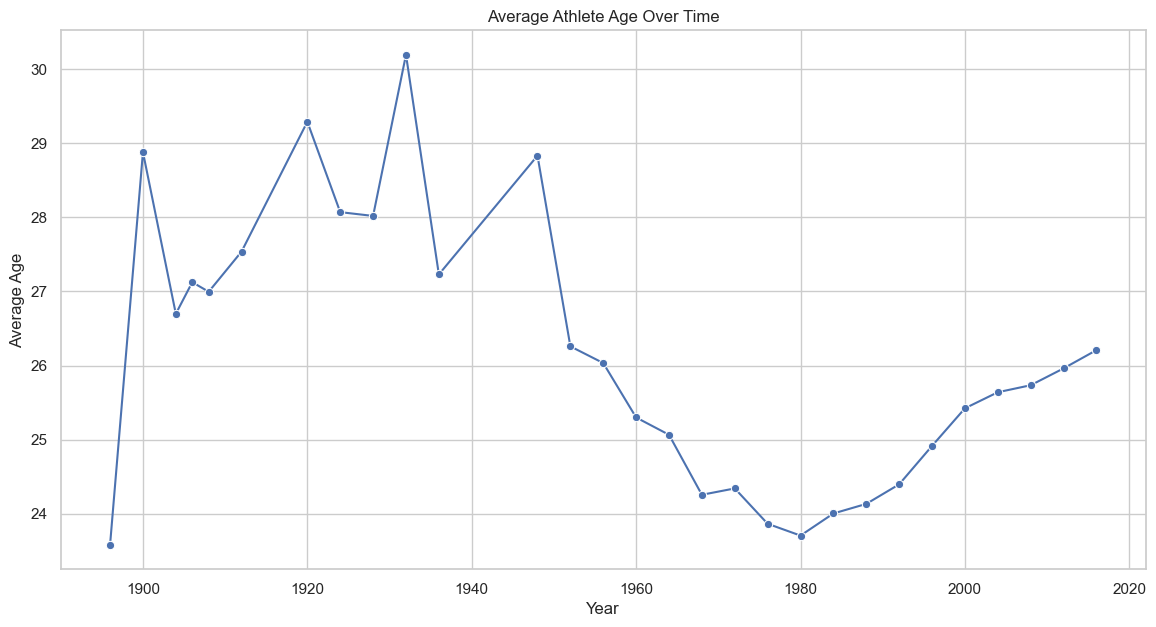

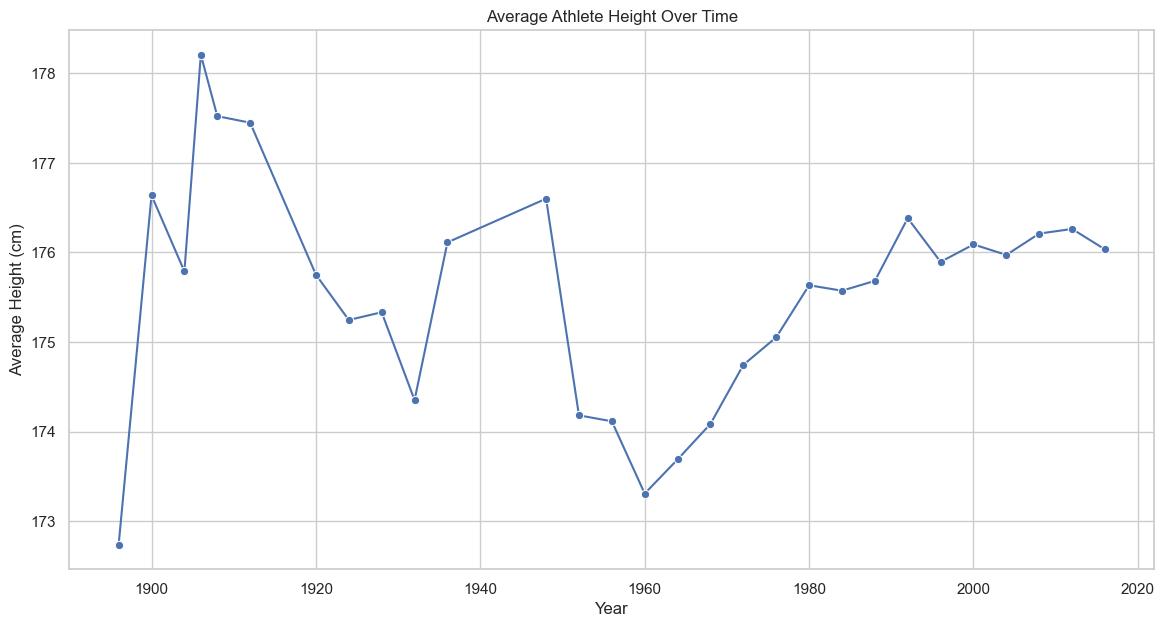

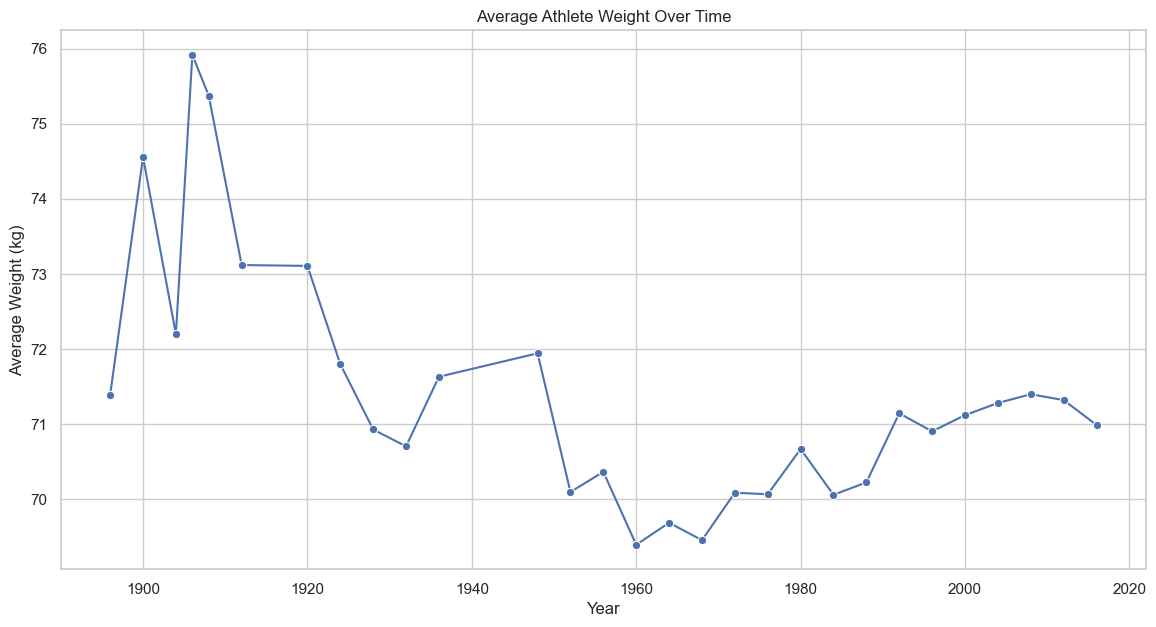

In [84]:
age = (
    df.groupby('Year')['Age']
    .mean()
    .reset_index()
)
#Line chart to see average age trend
plt.figure(figsize=(14,7))
sns.lineplot(
    data=age,
    x='Year',
    y='Age',
    marker='o'
)
plt.title('Average Athlete Age Over Time')
plt.xlabel('Year')
plt.ylabel('Average Age')
plt.show()

height = (
    df.groupby('Year')['Height']
    .mean()
    .reset_index()
)
#Line chart to see average height trend
plt.figure(figsize=(14,7))
sns.lineplot(
    data=height,
    x='Year',
    y='Height',
    marker='o'
)
plt.title('Average Athlete Height Over Time')
plt.xlabel('Year')
plt.ylabel('Average Height (cm)')
plt.show()

weight = (
    df.groupby('Year')['Weight']
    .mean()
    .reset_index()
)
#Line chart to see average weight trend
plt.figure(figsize=(14,7))
sns.lineplot(
    data=weight,
    x='Year',
    y='Weight',
    marker='o'
)
plt.title('Average Athlete Weight Over Time')
plt.xlabel('Year')
plt.ylabel('Average Weight (kg)')
plt.show()

**PART 4** : Medal counts before and after hosting the olympics

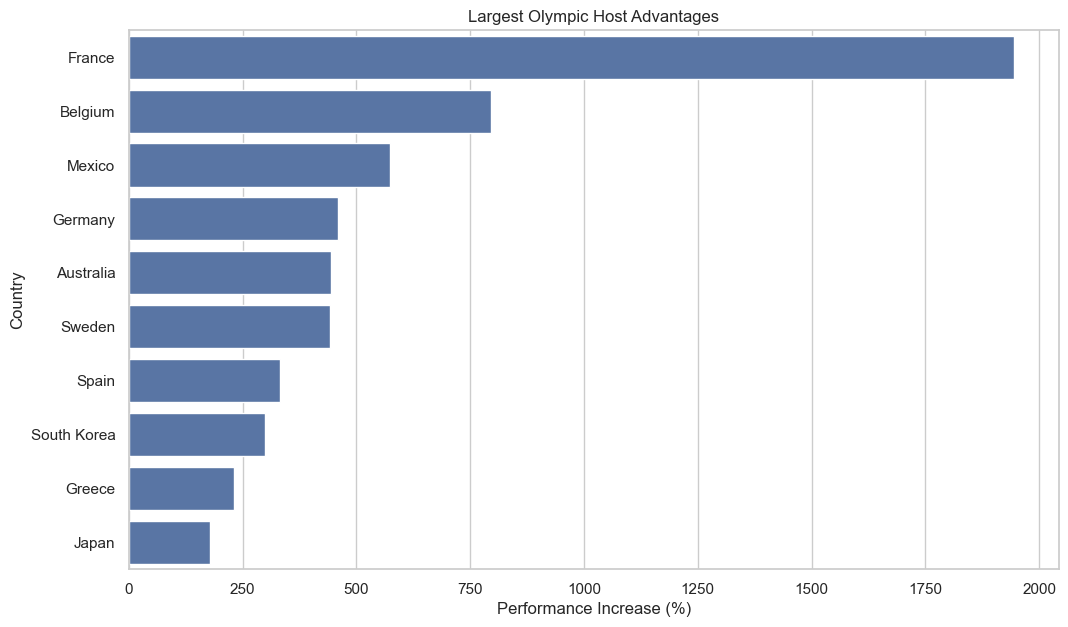

In [85]:
#Host country table
hosts = {
    1896:'Greece',
    1900:'France',
    1904:'United States',
    1908:'United Kingdom',
    1912:'Sweden',
    1920:'Belgium',
    1924:'France',
    1928:'Netherlands',
    1932:'United States',
    1936:'Germany',
    1948:'United Kingdom',
    1952:'Finland',
    1956:'Australia',
    1960:'Italy',
    1964:'Japan',
    1968:'Mexico',
    1972:'Germany',
    1976:'Canada',
    1980:'Soviet Union',
    1984:'United States',
    1988:'South Korea',
    1992:'Spain',
    1996:'United States',
    2000:'Australia',
    2004:'Greece',
    2008:'China',
    2012:'United Kingdom',
    2016:'Brazil',
    2020:'Japan'
}
#Medal by year and country
medal_table = (
    df[df['Medal'] != 'No Medal']
    .groupby(['region', 'Year'],observed=False)
    .size()
    .reset_index(name='Medals')
)

#Finding host advantage
host_advantage = []
for host_year, country in hosts.items():
    country_data = medal_table[
        medal_table['region'] == country
    ].sort_values('Year')
    previous_three = (
        country_data[
            country_data['Year'] < host_year
        ]
        .tail(3)
    )
    if len(previous_three) == 0:
        continue
    previous_avg = previous_three['Medals'].mean()
    host_medals = country_data[
        country_data['Year'] == host_year
    ]
    if len(host_medals) == 0:
        continue
    host_medals = host_medals.iloc[0]['Medals']
    next_three = (
        country_data[
            country_data['Year'] > host_year
        ]
        .head(3)
    )
    after_avg = (
        next_three['Medals'].mean()
        if len(next_three) > 0
        else np.nan
    )
    host_boost = (
        (host_medals - previous_avg)
        / previous_avg
    ) * 100
    host_advantage.append({
        'Country': country,
        'Host_Year': host_year,
        'Previous_3_Avg': previous_avg,
        'Host_Medals': host_medals,
        'Next_3_Avg': after_avg,
        'Host_Boost_%': host_boost
    })

host_df = pd.DataFrame(host_advantage) #Host dataframe
host_df = host_df.sort_values(
    'Host_Boost_%',
    ascending=False
)

plt.figure(figsize=(12,7))
sns.barplot(
    data=host_df.head(10),
    x='Host_Boost_%',
    y='Country'
)
plt.title('Largest Olympic Host Advantages')
plt.xlabel('Performance Increase (%)')
plt.ylabel('Country')
plt.show()